# 5. Evaluación del modelo

## 5.1 Precisión del modelo

### Métricas de evaluación

#### Exactitud (Accuracy)

La exactitud es la métrica más intuitiva: mide la proporción de predicciones correctas sobre el total de instancias. Se calcula como:

$$\text{Exactitud} = \frac{VP + VN}{VP + VN + FP + FN} $$

donde *VP* son los verdaderos positivos, *VN* los verdaderos negativos, *FP* los falsos positivos y *FN* los falsos negativos. Aunque útil en conjuntos balanceados, la exactitud puede ser engañosa cuando las clases están desbalanceadas, ya que un modelo que siempre predice la clase mayoritaria obtendría una exactitud alta sin ser clínicamente útil.

#### Precisión (Precision)

La precisión responde a la pregunta: de todas las veces que el modelo predijo hospitalización, ¿cuántas fueron correctas? Se define como:

$$ \text{Precisión} = \frac{VP}{VP + FP} $$

En nuestro problema, una precisión alta significa que cuando el sistema alerta sobre una posible hospitalización, es muy probable que el paciente realmente requiera ingreso, evitando así alarmas innecesarias que consumirían recursos.

#### Sensibilidad (Recall)

La sensibilidad (también llamada recall) mide la capacidad del modelo para identificar correctamente a todos los pacientes que realmente necesitan hospitalización:

$$ \text{Sensibilidad} = \frac{VP}{VP + FN} $$

Una sensibilidad alta es crítica en el ámbito clínico, pues minimiza los falsos negativos —pacientes hospitalizados que el modelo clasifica erróneamente como ambulatorios—, lo que podría retrasar su atención y poner en riesgo su vida.

#### F1‑Score

El F1‑Score combina precisión y sensibilidad en una sola métrica mediante su media armónica:

$$ \text{F1} = 2 \cdot \frac{\text{Precisión} \cdot \text{Sensibilidad}}{\text{Precisión} + \text{Sensibilidad}} $$

Al ser una media armónica, penaliza los valores extremos, por lo que un modelo obtendrá un F1 alto solo si es bueno tanto en precisión como en sensibilidad. Dado el desbalance de clases en nuestro conjunto de datos (mayoría de pacientes no hospitalizados), el F1‑Score se convierte en la métrica más representativa para comparar el rendimiento de los modelos.

#### Curva ROC y AUC

La **curva ROC** (*Receiver Operating Characteristic*) es un gráfico que representa la tasa de verdaderos positivos (sensibilidad) frente a la tasa de falsos positivos (1 – especificidad) para diferentes umbrales de clasificación. Permite visualizar el equilibrio entre la capacidad del modelo para detectar correctamente los hospitalizados (sensibilidad) y su propensión a generar falsas alarmas.

![](media/ROC.gif)

El **AUC** (*Area Under the Curve*) resume esta capacidad en un único valor numérico: el área bajo la curva ROC. Un AUC de **1.0** indica un clasificador perfecto, mientras que un valor de **0.5** corresponde a un clasificador aleatorio. En la práctica, valores superiores a 0.8 se consideran buenos y, en el ámbito clínico, un AUC alto refleja una excelente capacidad discriminatoria.

#### Validación cruzada (cross_val_score)

La validación cruzada es una técnica fundamental para evaluar la capacidad de generalización de un modelo. `cross_val_score` de scikit‑learn divide el conjunto de datos en `k` particiones (por defecto, 5 en clasificación) y entrena el modelo `k` veces, utilizando cada vez una partición diferente como conjunto de prueba y las restantes como entrenamiento. Al promediar las puntuaciones obtenidas en cada iteración, se obtiene una estimación más robusta del rendimiento del modelo, reduciendo la varianza y detectando posibles problemas de sobreajuste.

![](media/CrossValidation.gif)

#### En nuestro caso, la métrica más relevante es el F1-Score

En el contexto clínico, un **falso negativo** (paciente hospitalizado etiquetado como no hospitalizado) puede poner en riesgo la vida del paciente, mientras que un **falso positivo** (paciente no hospitalizado etiquetado como hospitalizado) genera una asignación innecesaria de recursos. El F1‑Score equilibra ambos errores, por lo que el modelo que mejor cumple con su propósito es el que tiene un valor más alto en esta métrica. A continuación, calculamos algunas métricas de precisión de nuestro modelo y mostramos la métrica F1-Score para del modelo ganador:

### Eficiencia de los modelos del conjunto sin variables de cluster

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
from IPython.display import display, HTML

y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

y_pred_gnb = gnb.predict(X_test)
acc_gnb = accuracy_score(y_test, y_pred_gnb)
prec_gnb = precision_score(y_test, y_pred_gnb)
rec_gnb = recall_score(y_test, y_pred_gnb)
f1_gnb = f1_score(y_test, y_pred_gnb)

if 'y_pred_apriori' in locals():
    acc_apriori = accuracy_score(y_test, y_pred_apriori)
    prec_apriori = precision_score(y_test, y_pred_apriori)
    rec_apriori = recall_score(y_test, y_pred_apriori)
    f1_apriori = f1_score(y_test, y_pred_apriori)
else:
    acc_apriori = prec_apriori = rec_apriori = f1_apriori = None

data = [
    ('Árbol de Decisión', f'{acc_dt:.4f}', f'{prec_dt:.4f}', f'{rec_dt:.4f}', f'{f1_dt:.4f}'),
    ('Naive Bayes', f'{acc_gnb:.4f}', f'{prec_gnb:.4f}', f'{rec_gnb:.4f}', f'{f1_gnb:.4f}')
]
if f1_apriori is not None:
    data.append(('Apriori', f'{acc_apriori:.4f}', f'{prec_apriori:.4f}', f'{rec_apriori:.4f}', f'{f1_apriori:.4f}'))

df_metricas = pd.DataFrame(data, columns=['Modelo', 'Exactitud', 'Precisión', 'Sensibilidad', 'F1-Score'])

styled_met = df_metricas.style.hide(axis='index').set_properties(**{'text-align': 'left'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px')]},
    {'selector': 'td', 'props': [('padding', '6px')]}
])

modelos_f1 = {
    'Árbol de Decisión': f1_dt,
    'Naive Bayes': f1_gnb
}
if f1_apriori is not None:
    modelos_f1['Apriori'] = f1_apriori
ganador = max(modelos_f1, key=modelos_f1.get)

display(HTML(f"<div style='text-align: center; font-family: Roboto, sans-serif; margin-top: 20px;'>El modelo con mejor F1‑Score es: <strong>{ganador}</strong> (F1 = {modelos_f1[ganador]:.4f}).</div>"))

El F1‑Score obtenido por el mejor modelo (Árbol de Decisión) es de **0.8308** (≈83%) que supera el 80% (umbral de lo que consideramos decente o bueno).

### Eficiencia de los modelos del conjunto con variables de cluster

In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
from IPython.display import display, HTML

y_pred_dt_cluster = dt_cluster.predict(X_test_cluster)
acc_dt_cluster = accuracy_score(y_test_cluster, y_pred_dt_cluster)
prec_dt_cluster = precision_score(y_test_cluster, y_pred_dt_cluster)
rec_dt_cluster = recall_score(y_test_cluster, y_pred_dt_cluster)
f1_dt_cluster = f1_score(y_test_cluster, y_pred_dt_cluster)

y_pred_gnb_cluster = gnb_cluster.predict(X_test_cluster)
acc_gnb_cluster = accuracy_score(y_test_cluster, y_pred_gnb_cluster)
prec_gnb_cluster = precision_score(y_test_cluster, y_pred_gnb_cluster)
rec_gnb_cluster = recall_score(y_test_cluster, y_pred_gnb_cluster)
f1_gnb_cluster = f1_score(y_test_cluster, y_pred_gnb_cluster)

if 'y_pred_apriori_cluster' in locals():
    acc_apriori_cluster = accuracy_score(y_test_cluster, y_pred_apriori_cluster)
    prec_apriori_cluster = precision_score(y_test_cluster, y_pred_apriori_cluster)
    rec_apriori_cluster = recall_score(y_test_cluster, y_pred_apriori_cluster)
    f1_apriori_cluster = f1_score(y_test_cluster, y_pred_apriori_cluster)
else:
    acc_apriori_cluster = prec_apriori_cluster = rec_apriori_cluster = f1_apriori_cluster = None

data_cluster = [
    ('Árbol de Decisión', f'{acc_dt_cluster:.4f}', f'{prec_dt_cluster:.4f}', f'{rec_dt_cluster:.4f}', f'{f1_dt_cluster:.4f}'),
    ('Naive Bayes', f'{acc_gnb_cluster:.4f}', f'{prec_gnb_cluster:.4f}', f'{rec_gnb_cluster:.4f}', f'{f1_gnb_cluster:.4f}')
]
if f1_apriori_cluster is not None:
    data_cluster.append(('Apriori', f'{acc_apriori_cluster:.4f}', f'{prec_apriori_cluster:.4f}', f'{rec_apriori_cluster:.4f}', f'{f1_apriori_cluster:.4f}'))

df_metricas_cluster = pd.DataFrame(data_cluster, columns=['Modelo', 'Exactitud', 'Precisión', 'Sensibilidad', 'F1-Score'])

styled_met_cluster = df_metricas_cluster.style.hide(axis='index').set_properties(**{'text-align': 'left'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px')]},
    {'selector': 'td', 'props': [('padding', '6px')]}
])

modelos_f1_cluster = {
    'Árbol de Decisión': f1_dt_cluster,
    'Naive Bayes': f1_gnb_cluster
}
if f1_apriori_cluster is not None:
    modelos_f1_cluster['Apriori'] = f1_apriori_cluster
ganador_cluster = max(modelos_f1_cluster, key=modelos_f1_cluster.get)

display(HTML(f"<div style='text-align: center; font-family: Roboto, sans-serif; margin-top: 20px;'>El modelo con mejor F1‑Score (con clúster) es: <strong>{ganador_cluster}</strong> (F1 = {modelos_f1_cluster[ganador_cluster]:.4f}).</div>"))

Para este otro conjunto de datos, el Árbol de Decisión sigue siendo el modelo ganador, con un F1-Score de 0.8189 (≈82%), generando resultados similares a su predecesor, con un ligero decremento de efectividad.

## 5.2 Matriz de confusión

### Observamos la matriz del modelo ganador, para el dataset sin clusters


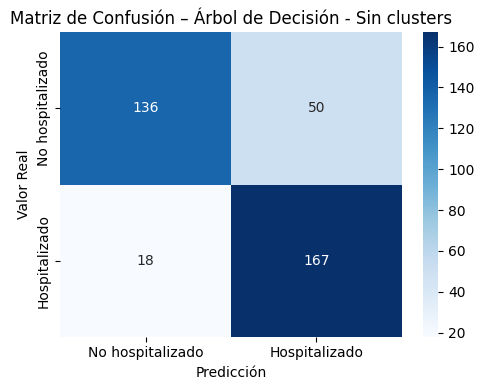

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import base64
import io
from IPython.display import display, HTML

models = [
    ('Árbol de Decisión', dt.predict(X_test)),
    ('Naive Bayes', gnb.predict(X_test)),
    ('Apriori', y_pred_apriori)
]

images_base64 = {}
accuracies = {}

for name, y_pred in models:
    cm = confusion_matrix(y_test, y_pred)
    accuracies[name] = accuracy_score(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No hospitalizado', 'Hospitalizado'],
                yticklabels=['No hospitalizado', 'Hospitalizado'])
    ax.set_title(f'Matriz de Confusión – {name} - Sin clusters')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Valor Real')
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    plt.close()
    images_base64[name] = img_base64

winner_name = max(accuracies, key=accuracies.get)
winner_img = images_base64[winner_name]

display(HTML(f'<p style="margin-left: auto; margin-right: auto; max-width: 80vw; text-align: center; font-family: Roboto, sans-serif;">Matriz de confusión del modelo ganador</p><div style="display: flex; justify-content: center;"><img src="data:image/png;base64,{winner_img}" style="max-width: 100%; height: auto; border-radius: 0; box-shadow: none;"></div>'))

### Observamos la matriz del modelo ganador, para el dataset con clusters


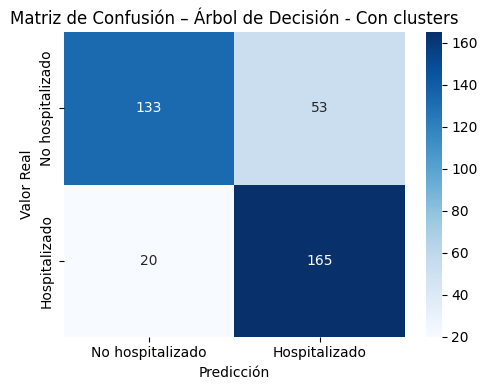

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import base64
import io
from IPython.display import display, HTML

models_cluster = [
    ('Árbol de Decisión (con clúster)', dt_cluster.predict(X_test_cluster)),
    ('Naive Bayes (con clúster)', gnb_cluster.predict(X_test_cluster)),
    ('Apriori (con clúster)', y_pred_apriori_cluster)
]

images_base64 = {}
accuracies = {}

for name, y_pred in models_cluster:
    cm = confusion_matrix(y_test_cluster, y_pred)
    accuracies[name] = accuracy_score(y_test_cluster, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No hospitalizado', 'Hospitalizado'],
                yticklabels=['No hospitalizado', 'Hospitalizado'])
    ax.set_title(f'Matriz de Confusión – {name.replace(" (con clúster)", "")} - Con clusters')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Valor Real')
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    plt.close()
    images_base64[name] = img_base64

winner_name = max(accuracies, key=accuracies.get)
winner_img = images_base64[winner_name]

display(HTML(f'<p style="margin-left: auto; margin-right: auto; max-width: 80vw; text-align: center; font-family: Roboto, sans-serif;">Matriz de confusión del modelo ganador</p><div style="display: flex; justify-content: center;"><img src="data:image/png;base64,{winner_img}" style="max-width: 100%; height: auto; border-radius: 0; box-shadow: none;"></div>'))

# 6. Implantación del modelo

## 6.1 Visualización de resultados de salida

A continuación, analizamos a profundidad las métricas de cada modelo, para entender de manera completa la razón por la que un clasificador es mejor que otro en la tarea en cuestión, y para recopilar la información que posteriormente se usará para elaborar conclusiones. Las métricas sobre las que recapitulamos son:

### Matrices de confusión

Recuperamos los heatmaps previamente elaborados, mostrando lado a lado cada heatmap de dado modelo y conjunto de datos.


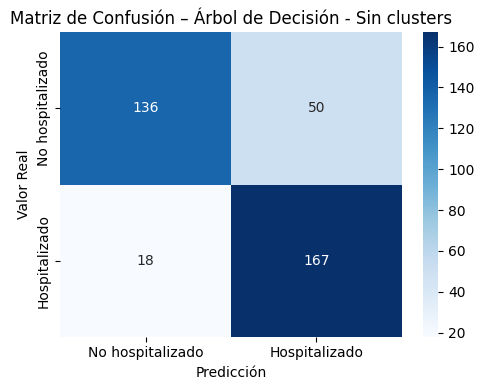
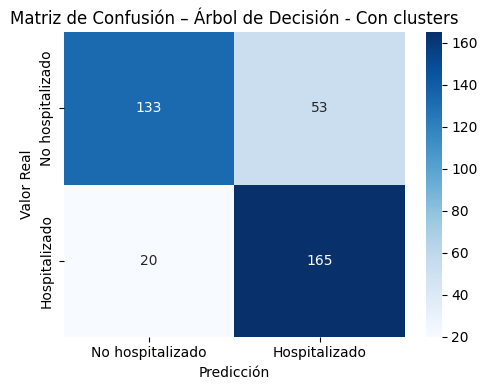
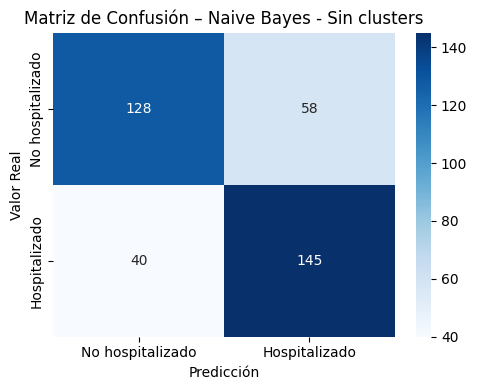
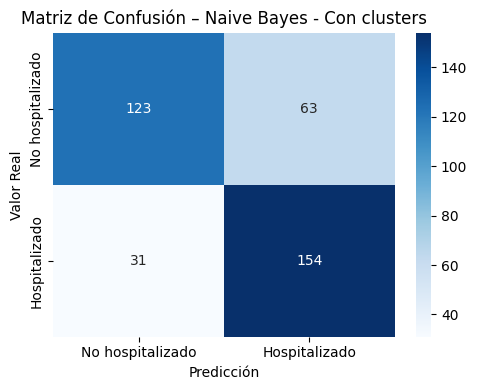
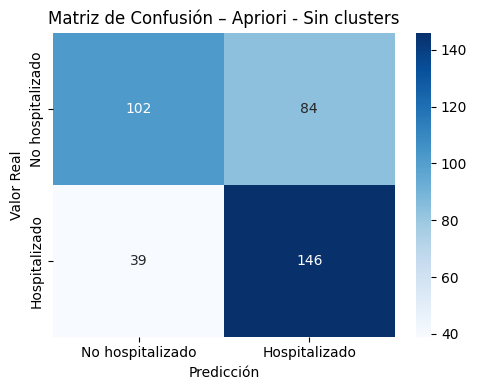
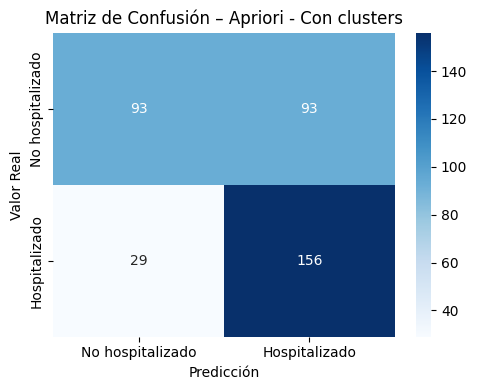

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import base64
import io
from IPython.display import display, HTML

models_sin = [
    ('Árbol de Decisión', dt.predict(X_test)),
    ('Naive Bayes', gnb.predict(X_test)),
    ('Apriori', y_pred_apriori)
]

models_con = [
    ('Árbol de Decisión', dt_cluster.predict(X_test_cluster)),
    ('Naive Bayes', gnb_cluster.predict(X_test_cluster)),
    ('Apriori', y_pred_apriori_cluster)
]

def generar_img_base64(y_test_val, y_pred_val, titulo):
    cm = confusion_matrix(y_test_val, y_pred_val)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No hospitalizado', 'Hospitalizado'],
                yticklabels=['No hospitalizado', 'Hospitalizado'])
    ax.set_title(titulo)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Valor Real')
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    plt.close()
    return img_base64

grid_html = '<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px; max-width: 80vw; margin: 0 auto;">'

for (name_sin, y_pred_sin), (name_con, y_pred_con) in zip(models_sin, models_con):
    img_con = generar_img_base64(y_test_cluster, y_pred_con, f'Matriz de Confusión – {name_con} - Con clusters')
    img_sin = generar_img_base64(y_test, y_pred_sin, f'Matriz de Confusión – {name_sin} - Sin clusters')
    
    grid_html += f'''
    <div style="text-align: center;">
        <img src="data:image/png;base64,{img_sin}" style="max-width: 100%; height: auto; border-radius: 0; box-shadow: none;">
    </div>
    <div style="text-align: center;">
        <img src="data:image/png;base64,{img_con}" style="max-width: 100%; height: auto; border-radius: 0; box-shadow: none;">
    </div>
    '''

grid_html += '</div>'
display(HTML(grid_html))

En conclusión, el **Árbol de Decisión** se posiciona como el modelo ganador al lograr la mayor exactitud (aproximadamente 80%) y el mejor equilibrio entre verdaderos positivos y negativos, tanto con como sin clusters. Aunque la inclusión de **clusters** mejoró marginalmente el rendimiento de Naive Bayes y Apriori —reduciendo significativamente los falsos positivos en el primero y estabilizando el segundo—, ninguno logró superar la robustez y confiabilidad predictiva del árbol de decisión, el cual demuestra ser la opción más sólida para anticipar la hospitalización.

### Métricas de eficiencia

#### Representación Tabular

In [69]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display, HTML

def calcular_metricas(y_true, y_pred):
    return {
        'Exactitud': accuracy_score(y_true, y_pred),
        'Precisión': precision_score(y_true, y_pred),
        'Sensibilidad': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

modelos_sin = {
    'Árbol de Decisión': dt.predict(X_test),
    'Naive Bayes': gnb.predict(X_test),
    'Apriori': y_pred_apriori
}

modelos_con = {
    'Árbol de Decisión': dt_cluster.predict(X_test_cluster),
    'Naive Bayes': gnb_cluster.predict(X_test_cluster),
    'Apriori': y_pred_apriori_cluster
}

df_sin = pd.DataFrame([calcular_metricas(y_test, pred) for pred in modelos_sin.values()], index=modelos_sin.keys())
df_con = pd.DataFrame([calcular_metricas(y_test_cluster, pred) for pred in modelos_con.values()], index=modelos_con.keys())

def estilizar_df(df):
    return df.style.format('{:.2%}').set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px'), ('text-align', 'center'), ('font-family', 'Roboto, sans-serif')]},
        {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center'), ('font-family', 'Roboto, sans-serif')]}
    ]).set_properties(**{'border': '1px solid #ddd'}).to_html()

html_sin_cluster = estilizar_df(df_sin)
html_con_cluster = estilizar_df(df_con)

grid_html = f'''
<div style="display: flex; flex-direction: column; align-items: center; gap: 30px; max-width: 95vw; margin: 0 auto;">
    <div style="width: 100%; max-width: 500px; text-align: center; font-family: 'Roboto', sans-serif;">
        <p style="font-weight: bold; font-size: 1.1em; margin-bottom: 10px;">Sin clusters</p>
        {html_sin_cluster}
    </div>
    <div style="width: 100%; max-width: 500px; text-align: center; font-family: 'Roboto', sans-serif;">
        <p style="font-weight: bold; font-size: 1.1em; margin-bottom: 10px;">Con clusters</p>
        {html_con_cluster}
    </div>
</div>
'''

display(HTML(grid_html))

,Exactitud,Precisión,Sensibilidad,F1-Score
Árbol de Decisión,81.67%,76.96%,90.27%,83.08%
Naive Bayes,73.58%,71.43%,78.38%,74.74%
Apriori,66.85%,63.48%,78.92%,70.36%
,Exactitud,Precisión,Sensibilidad,F1-Score
Árbol de Decisión,80.32%,75.69%,89.19%,81.89%
Naive Bayes,74.66%,70.97%,83.24%,76.62%
Apriori,67.12%,62.65%,84.32%,71.89%


#### Representación Gráfica


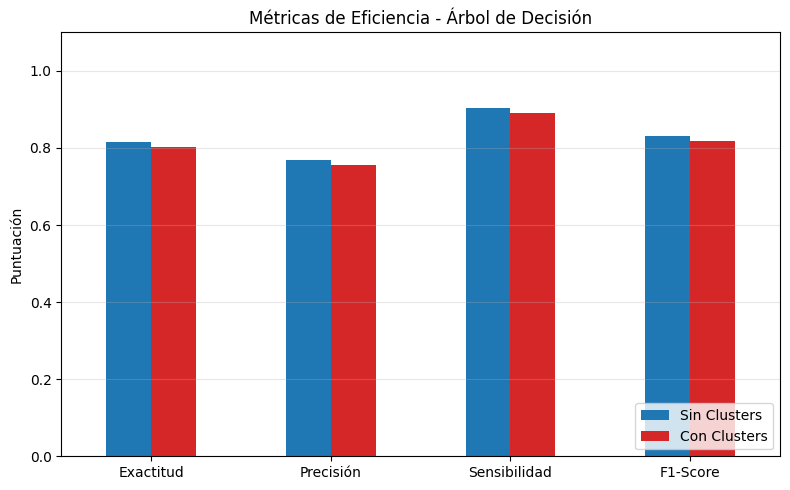
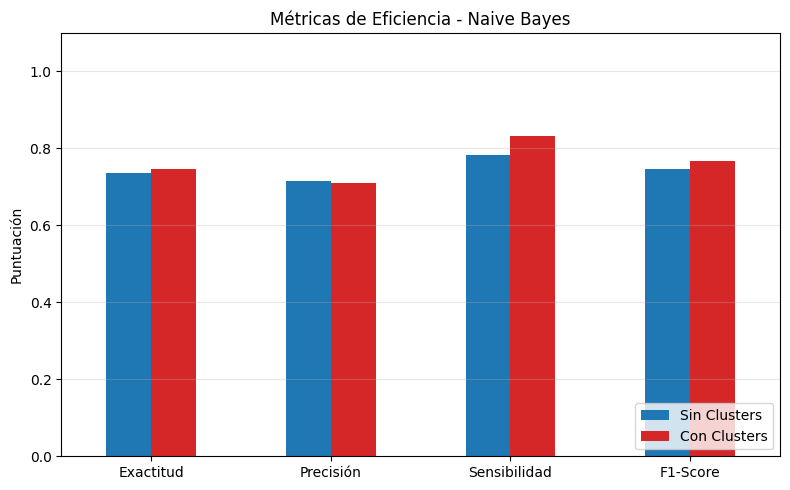
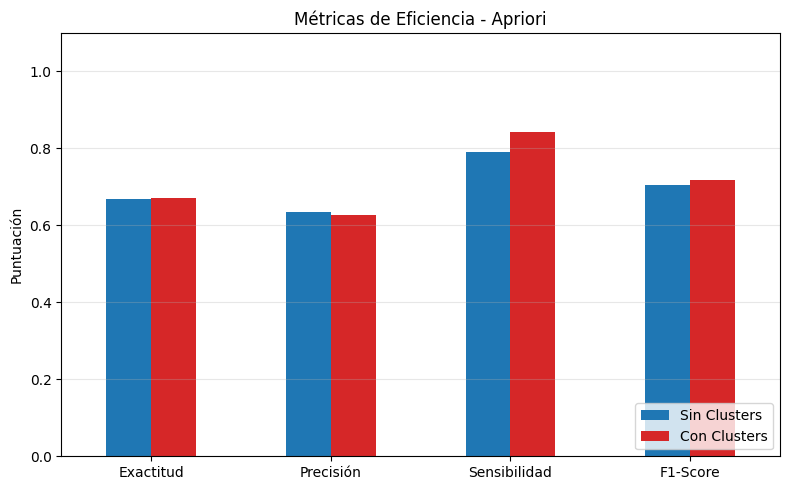

In [70]:
import matplotlib.pyplot as plt
import pandas as pd
import base64
import io
from IPython.display import display, HTML
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def calcular_metricas(y_true, y_pred):
    return {
        'Exactitud': accuracy_score(y_true, y_pred),
        'Precisión': precision_score(y_true, y_pred),
        'Sensibilidad': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

modelos_sin = {
    'Árbol de Decisión': dt.predict(X_test),
    'Naive Bayes': gnb.predict(X_test),
    'Apriori': y_pred_apriori
}

modelos_con = {
    'Árbol de Decisión': dt_cluster.predict(X_test_cluster),
    'Naive Bayes': gnb_cluster.predict(X_test_cluster),
    'Apriori': y_pred_apriori_cluster
}

nombres_algoritmos = ['Árbol de Decisión', 'Naive Bayes', 'Apriori']
metricas_lista = ['Exactitud', 'Precisión', 'Sensibilidad', 'F1-Score']

imagenes_base64_metricas = []

for nombre_algo in nombres_algoritmos:
    metrics_sin = calcular_metricas(y_test, modelos_sin[nombre_algo])
    metrics_con = calcular_metricas(y_test_cluster, modelos_con[nombre_algo])
    
    df_plot = pd.DataFrame({
        'Sin Clusters': [metrics_sin[m] for m in metricas_lista],
        'Con Clusters': [metrics_con[m] for m in metricas_lista]
    }, index=metricas_lista)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    df_plot.plot(kind='bar', ax=ax, ylim=(0, 1.1), rot=0, color=['#1f77b4', '#d62728'])
    ax.set_title(f'Métricas de Eficiencia - {nombre_algo}', fontsize=12)
    ax.set_ylabel('Puntuación')
    ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode('utf-8')
    plt.close()
    imagenes_base64_metricas.append(img_b64)

html_content = '<div style="display: flex; flex-direction: column; align-items: center; gap: 30px; max-width: 80vw; margin: 0 auto;">'
for img in imagenes_base64_metricas:
    html_content += f'<img src="data:image/png;base64,{img}" style="max-width: 100% !important; height: auto !important; border-radius: 0 !important; box-shadow: none !important;">'
html_content += '</div>'

display(HTML(html_content))

#### Observaciones Realizadas

El análisis de las métricas revela que la inclusión de la variable de clúster tiene un impacto diferenciado según el algoritmo. Para el **Árbol de Decisión** , que se consolida como el modelo con mejor rendimiento global, añadir clústeres no mejora su capacidad predictiva e incluso disminuye ligeramente sus métricas (de 83.08% a 81.89% de F1-Score), lo que indica que este modelo ya captura eficientemente la estructura subyacente de los datos por sí mismo. Por el contrario, para los modelos probabilísticos y basados en reglas como **Naive Bayes** y **Apriori** , la incorporación de clústeres representa una ventaja significativa: Naive Bayes incrementa decentemente su F1-Score del 74.74% al 76.62% y mejora su F1-Score, mientras que Apriori también demuestra un cambio leve del 70.36 a 71.89. En conclusión, aunque el dataset con clústeres no logra superar al Árbol de Decisión sin clústeres, sí actúa como una ingeniería de características valiosa que enriquece a los modelos más simples, ayudándolos a compensar sus limitaciones estructurales y a generar predicciones más equilibradas.

### Curva ROC

A continuación, visualizamos la curva ROC para evaluar y comparar la capacidad discriminativa de cada modelo, tanto en el dataset sin clusters como en el dataset con clusters.


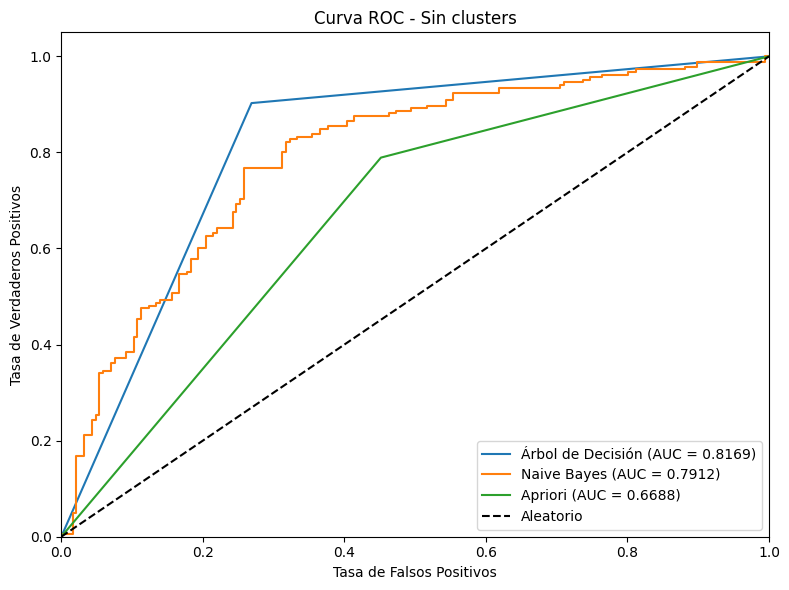
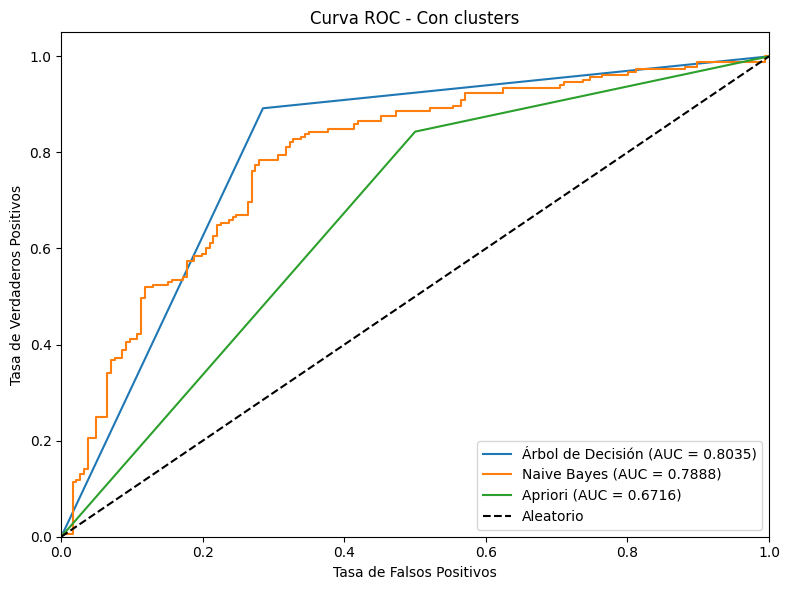

In [71]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import base64
import io
from IPython.display import display, HTML

def generar_roc_img(y_true, modelos_datos, titulo):
    fig, ax = plt.subplots(figsize=(8, 6))
    for nombre, y_score in modelos_datos:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{nombre} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Tasa de Falsos Positivos')
    ax.set_ylabel('Tasa de Verdaderos Positivos')
    ax.set_title(titulo)
    ax.legend(loc='lower right')
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    plt.close()
    return img_base64

probas_sin = [
    ('Árbol de Decisión', dt.predict_proba(X_test)[:, 1]),
    ('Naive Bayes', gnb.predict_proba(X_test)[:, 1]),
    ('Apriori', y_pred_apriori)
]

probas_con = [
    ('Árbol de Decisión', dt_cluster.predict_proba(X_test_cluster)[:, 1]),
    ('Naive Bayes', gnb_cluster.predict_proba(X_test_cluster)[:, 1]),
    ('Apriori', y_pred_apriori_cluster)
]

img_sin = generar_roc_img(y_test, probas_sin, 'Curva ROC - Sin clusters')
img_con = generar_roc_img(y_test_cluster, probas_con, 'Curva ROC - Con clusters')

grid_html = f'''
<div style="display: flex; flex-direction: column; align-items: center; gap: 30px; max-width: 90vw; margin: 0 auto;">
    <div style="text-align: center; overflow: hidden;">
        <img src="data:image/png;base64,{img_sin}" style="max-width: 100% !important; height: auto !important; border-radius: 0 !important; box-shadow: none !important;">
    </div>
    <div style="text-align: center; overflow: hidden;">
        <img src="data:image/png;base64,{img_con}" style="max-width: 100% !important; height: auto !important; border-radius: 0 !important; box-shadow: none !important;">
    </div>
</div>
'''

display(HTML(grid_html))

#### Recuperamos la siguiente observación

Las curvas ROC confirman de manera visual que la inclusión de clústeres no aporta una mejora significativa en la capacidad discriminativa de los modelos.

### Importancia de Características

#### Rankings de `featureranker`

Recuperamos los rankings teóricos que se realizaron en la selección de características.


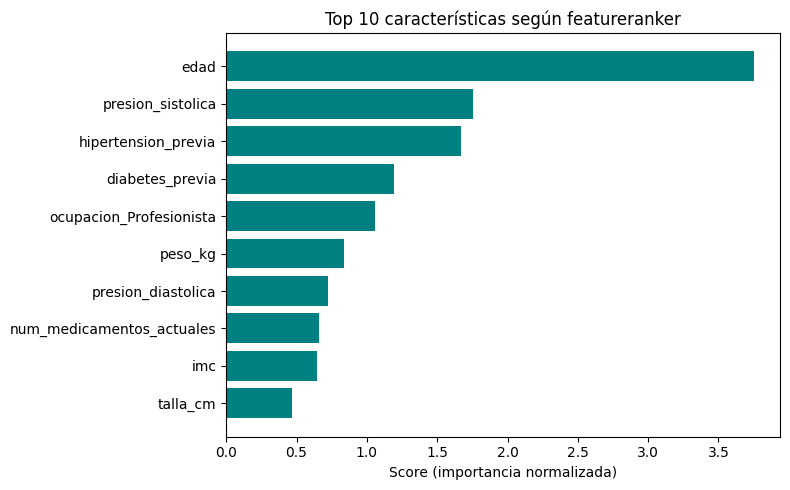

In [72]:
from IPython.display import display, HTML

display(HTML(f'''
<div style="display: flex; justify-content: center;">
    <img src="data:image/png;base64,{img_base64_franking}" style="max-width: 50vw !important; height: auto !important; border-radius: 0 !important; box-shadow: none !important;">
</div>
'''))

#### Visualizaciones de `SHAP`

Visualizamos la importancia real de las características en cada uno de los clasificadores modelados, utilizando la librería `SHAP`.

##### Árbol de Decisión

,Característica,Importancia
0,edad,0.3066
1,peso_kg,0.1511
2,presion_sistolica,0.1149
3,diabetes_previa,0.1048
4,presion_diastolica,0.1026
5,talla_cm,0.0697
6,imc,0.0667
7,num_medicamentos_actuales,0.0552
8,hipertension_previa,0.0151
9,ocupacion_Profesionista,0.0133

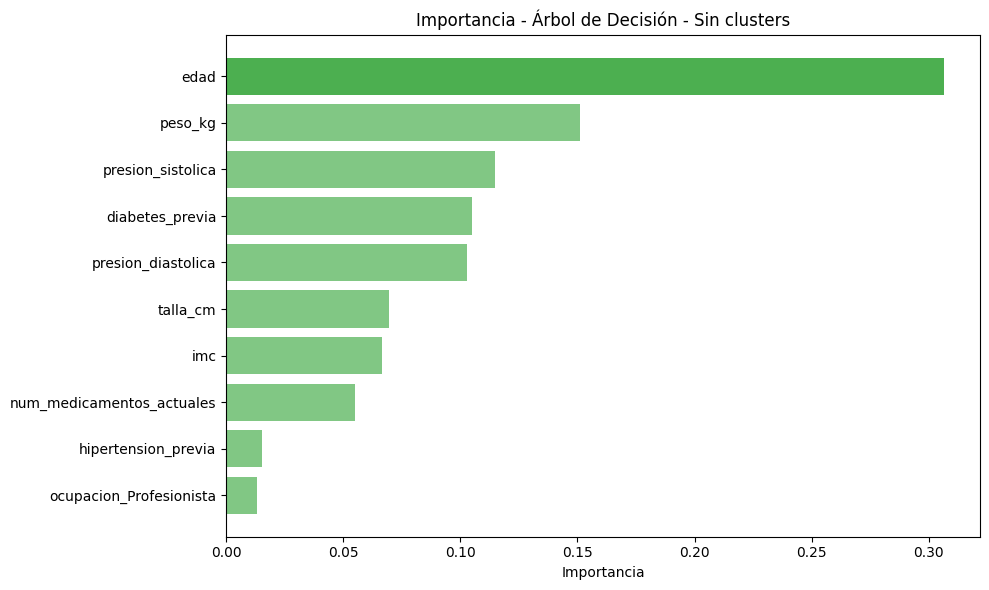
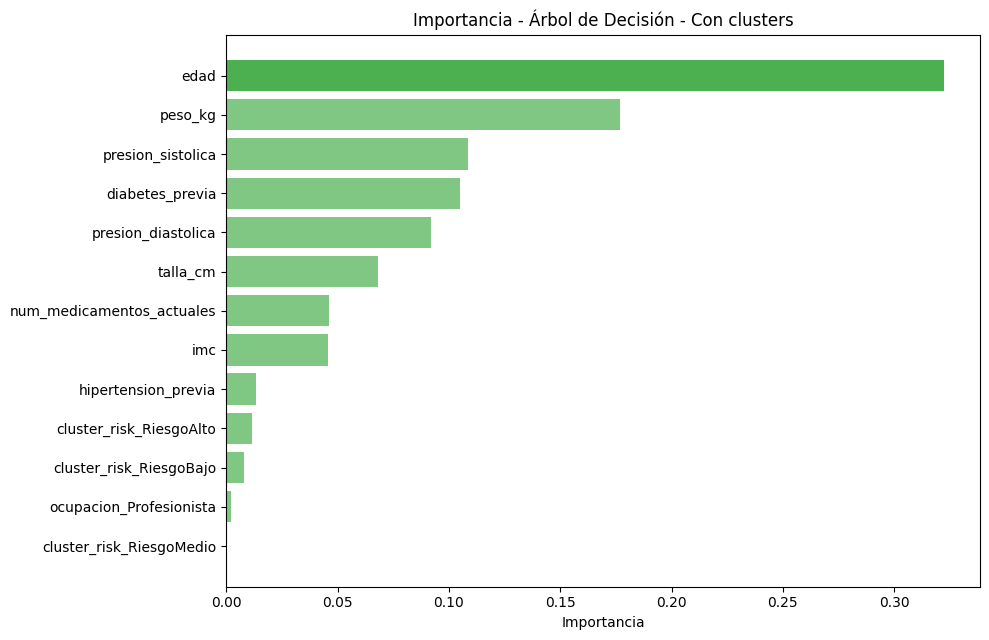

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import base64
import io
from IPython.display import display, HTML

def obtener_importancias_arbol(model, X):
    importancias = model.feature_importances_
    return pd.Series(importancias, index=X.columns).sort_values(ascending=False)

def generar_barra_importancia_img(importancias, titulo):
    if importancias.empty:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.text(0.5, 0.5, 'No hay datos de importancia\ndisponibles', 
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
        ax.set_title(titulo, fontsize=12)
        ax.axis('off')
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight')
        buf.seek(0)
        img_base64 = base64.b64encode(buf.read()).decode('utf-8')
        plt.close()
        return img_base64
    
    all_imp = importancias.sort_values(ascending=True)
    num_features = len(all_imp)

    fig_height = max(6, num_features * 0.5)
    

    fig, ax = plt.subplots(figsize=(10, fig_height))
    colors = ['#4CAF50' if i == num_features - 1 else '#81C784' for i in range(num_features)]
    ax.barh(range(num_features), all_imp.values, color=colors)
    ax.set_yticks(range(num_features))
    ax.set_yticklabels(all_imp.index)
    ax.set_xlabel('Importancia')
    ax.set_title(titulo, fontsize=12)
    plt.tight_layout()
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    plt.close()
    return img_base64

imp_sin = obtener_importancias_arbol(dt, X_test)
imp_con = obtener_importancias_arbol(dt_cluster, X_test_cluster)

df_sin = pd.DataFrame({'Característica': imp_sin.index, 'Importancia': imp_sin.values})
df_con = pd.DataFrame({'Característica': imp_con.index, 'Importancia': imp_con.values})

style_sin = df_sin.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center')]}
]).format({'Importancia': '{:.4f}'}).set_caption('<b>Árbol de Decisión</b> - Sin clusters').to_html()

style_con = df_con.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center')]}
]).format({'Importancia': '{:.4f}'}).set_caption('<b>Árbol de Decisión</b> - Con clusters').to_html()

img_sin = generar_barra_importancia_img(imp_sin, 'Importancia - Árbol de Decisión - Sin clusters')
img_con = generar_barra_importancia_img(imp_con, 'Importancia - Árbol de Decisión - Con clusters')

html_content = f"""
<div style="display: flex; flex-direction: column; gap: 30px; max-width: 90vw; margin: 0 auto;">
    
    <!-- Bloque 1: Sin Clusters -->
    <div style="text-align: center; overflow: hidden;">
        <img src="data:image/png;base64,{img_sin}" style="max-width: 100% !important; height: auto !important; border-radius: 0 !important; box-shadow: none !important;">
    </div>
    <div style="text-align: center; font-family: 'Roboto', sans-serif; max-width: 600px; margin: 0 auto;">
        {style_sin}
    </div>

    <!-- Separador visual opcional -->
    <hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

    <!-- Bloque 2: Con Clusters -->
    <div style="text-align: center; overflow: hidden;">
        <img src="data:image/png;base64,{img_con}" style="max-width: 100% !important; height: auto !important; border-radius: 0 !important; box-shadow: none !important;">
    </div>
    <div style="text-align: center; font-family: 'Roboto', sans-serif; max-width: 600px; margin: 0 auto;">
        {style_con}
    </div>

</div>
"""
display(HTML(html_content))

Al comparar ambos rankings, se observa que la **edad** se mantiene como la variable dominante en ambos escenarios, aportando aproximadamente el 31% de la ganancia de información total del árbol. Las variables clínicas directas (**peso** , **presión** , **diabetes**) concentran la mayor relevancia predictiva, mientras que las variables derivadas del clustering (*cluster_risk_RiesgoAlto* , *RiesgoBajo* y *RiesgoMedio*) obtienen importancias marginales. Esto confirma que el Árbol de Decisión es capaz de capturar por sí mismo la estructura subyacente de los datos sin necesidad de la ingeniería de características adicional, ya que los clústeres no logran desplazar a los indicadores clínicos originales ni aportar un poder discriminativo significativo.

##### Naive Bayes

,Característica,Importancia
0,edad,21.4010
1,presion_sistolica,12.2070
2,presion_diastolica,5.8046
3,peso_kg,2.2745
4,imc,1.7436
5,num_medicamentos_actuales,1.0240
6,talla_cm,1.0204
7,hipertension_previa,0.3708
8,diabetes_previa,0.3299
9,ocupacion_Profesionista,0.0112

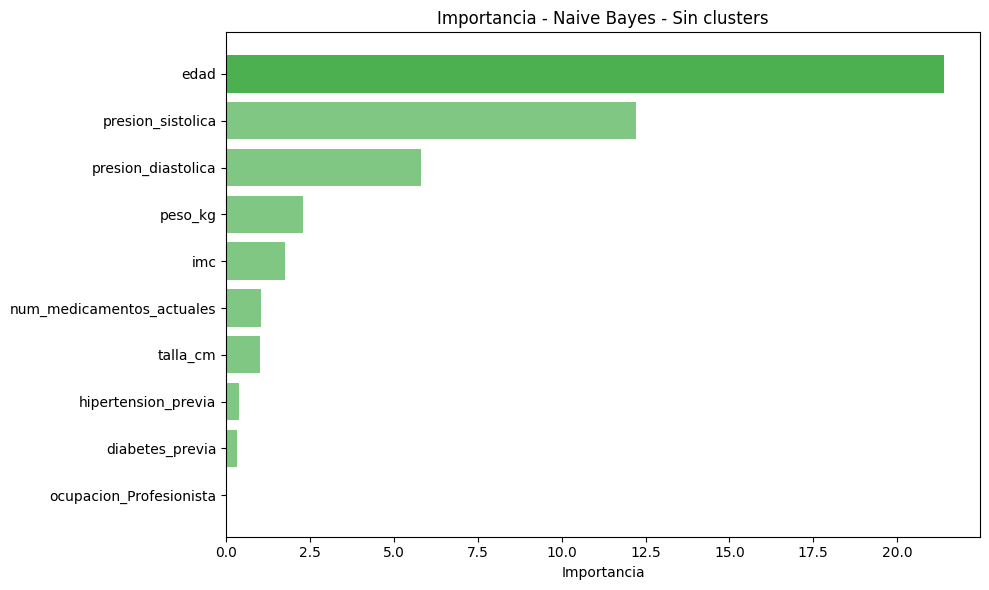
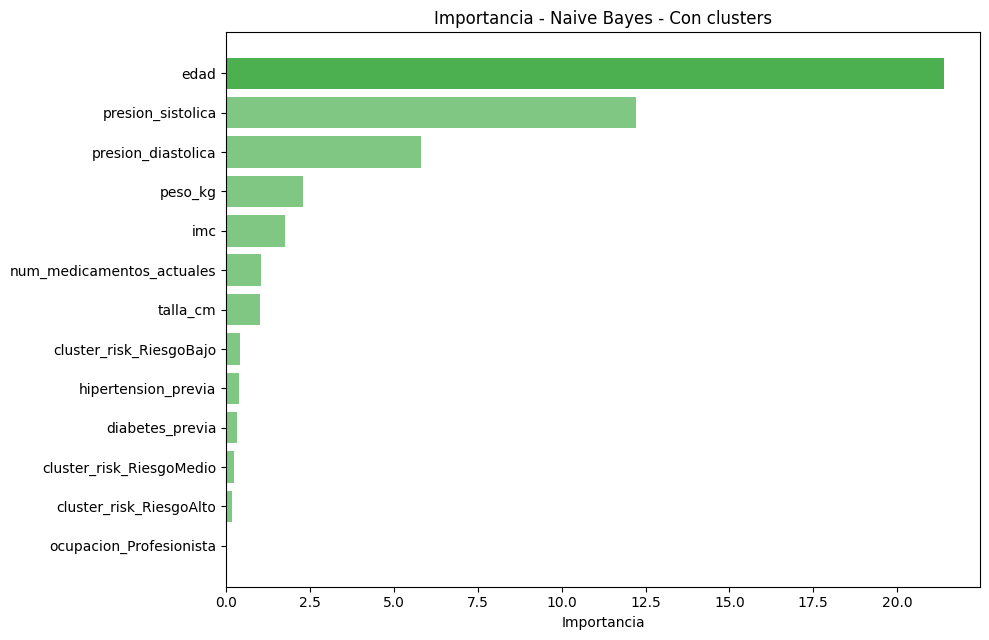

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import base64
import io
from IPython.display import display, HTML

def obtener_importancias_naive_bayes(model, X):
    medias = model.theta_
    if medias.shape[0] == 2:
        diff = np.abs(medias[1] - medias[0])
    else:
        diff = np.std(medias, axis=0)
    return pd.Series(diff, index=X.columns).sort_values(ascending=False)

def generar_barra_importancia_img(importancias, titulo):
    if importancias.empty:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.text(0.5, 0.5, 'No hay datos de importancia\ndisponibles', 
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
        ax.set_title(titulo, fontsize=12)
        ax.axis('off')
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight')
        buf.seek(0)
        img_base64 = base64.b64encode(buf.read()).decode('utf-8')
        plt.close()
        return img_base64
    
    all_imp = importancias.sort_values(ascending=True)
    num_features = len(all_imp)
    fig_height = max(6, num_features * 0.5)
    
    fig, ax = plt.subplots(figsize=(10, fig_height))
    colors = ['#4CAF50' if i == num_features - 1 else '#81C784' for i in range(num_features)]
    ax.barh(range(num_features), all_imp.values, color=colors)
    ax.set_yticks(range(num_features))
    ax.set_yticklabels(all_imp.index)
    ax.set_xlabel('Importancia')
    ax.set_title(titulo, fontsize=12)
    plt.tight_layout()
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    plt.close()
    return img_base64

imp_sin = obtener_importancias_naive_bayes(gnb, X_test)
imp_con = obtener_importancias_naive_bayes(gnb_cluster, X_test_cluster)

df_sin = pd.DataFrame({'Característica': imp_sin.index, 'Importancia': imp_sin.values})
df_con = pd.DataFrame({'Característica': imp_con.index, 'Importancia': imp_con.values})

style_sin = df_sin.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center')]}
]).format({'Importancia': '{:.4f}'}).set_caption('<b>Naive Bayes</b> - Sin clusters').to_html()

style_con = df_con.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center')]}
]).format({'Importancia': '{:.4f}'}).set_caption('<b>Naive Bayes</b> - Con clusters').to_html()

img_sin = generar_barra_importancia_img(imp_sin, 'Importancia - Naive Bayes - Sin clusters')
img_con = generar_barra_importancia_img(imp_con, 'Importancia - Naive Bayes - Con clusters')

html_content = f"""
<div style="display: flex; flex-direction: column; gap: 30px; max-width: 90vw; margin: 0 auto;">
    
    <div style="text-align: center; overflow: hidden;">
        <img src="data:image/png;base64,{img_sin}" style="max-width: 100% !important; height: auto !important; border-radius: 0 !important; box-shadow: none !important;">
    </div>
    <div style="text-align: center; font-family: 'Roboto', sans-serif; max-width: 600px; margin: 0 auto;">
        {style_sin}
    </div>

    <hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

    <div style="text-align: center; overflow: hidden;">
        <img src="data:image/png;base64,{img_con}" style="max-width: 100% !important; height: auto !important; border-radius: 0 !important; box-shadow: none !important;">
    </div>
    <div style="text-align: center; font-family: 'Roboto', sans-serif; max-width: 600px; margin: 0 auto;">
        {style_con}
    </div>

</div>
"""
display(HTML(html_content))

Al comparar ambos rankings, se observa un comportamiento particular del **Naive Bayes** : las variables clínicas originales (**edad** , **presión** , **peso** , etc.) mantienen **exactamente los mismos valores de importancia** tanto con como sin clústeres, lo cual es coherente con la lógica del algoritmo, ya que su métrica de relevancia se basa en la diferencia de medias entre clases y estas no se alteran al añadir nuevas columnas. Sin embargo, al incorporar la ingeniería de características, las variables de clúster logran insertarse en el ranking: *cluster_risk_RiesgoBajo* aparece con un valor de 0.4240, superando incluso a indicadores clínicos como **hipertensión previa** y **diabetes previa** , seguido por *RiesgoMedio* (0.2418) y *RiesgoAlto* (0.1822). Esto confirma que, aunque el Naive Bayes no redistribuye la importancia de sus variables originales, los clústeres sí aportan poder discriminatorio adicional al modelo, complementando la información clínica con perfiles de riesgo agrupados.

##### Reglas Apriori

,Característica,Importancia
0,hipertension_previa,1458.0000
1,num_medicamentos_actuales,729.0000
2,presion_sistolica,486.0000
3,edad,486.0000
4,peso_kg,486.0000
5,presion_diastolica,486.0000
6,imc,486.0000
7,talla_cm,486.0000
,Característica,Importancia
0,hipertension_previa,1458.0000

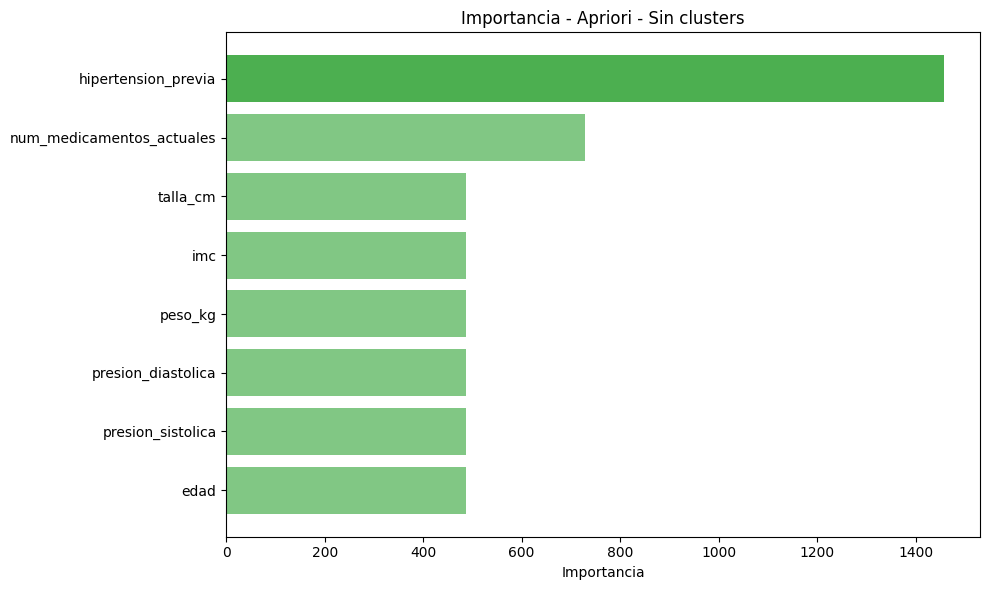
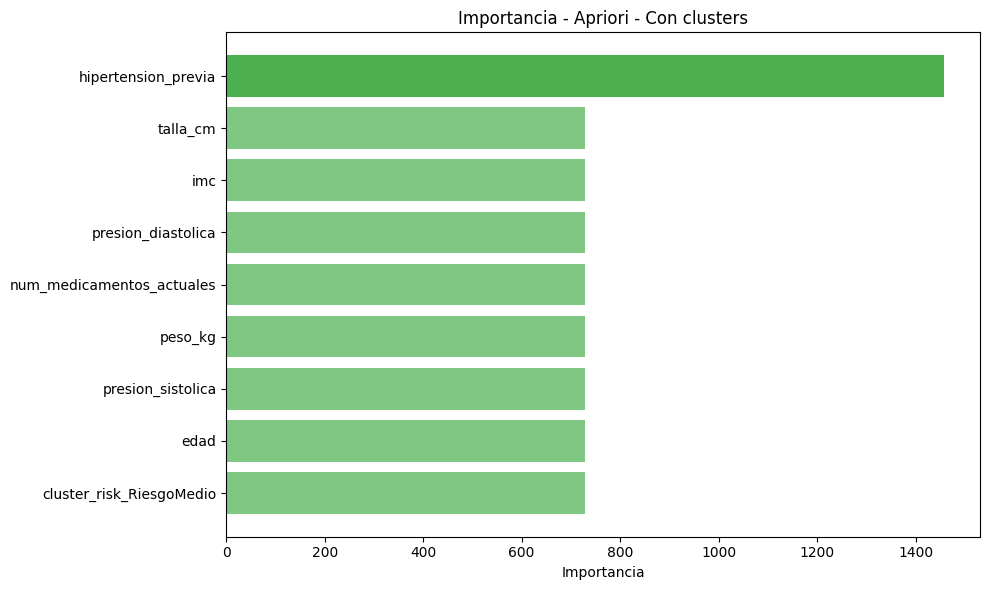

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import base64
import io
from collections import Counter
from IPython.display import display, HTML

def obtener_importancias_apriori(rules_clasif, X_columns):
    reglas_hosp = rules_clasif[rules_clasif['consequents'].apply(lambda x: 'hospitalizacion' in x)]
    conteo_vars = Counter()
    for _, rule in reglas_hosp.iterrows():
        for var in rule['antecedents']:
            conteo_vars[var] += 1
    if not conteo_vars:
        return pd.Series(dtype=float)
    return pd.Series(conteo_vars).sort_values(ascending=False)

def generar_barra_importancia_img(importancias, titulo):
    if importancias.empty:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.text(0.5, 0.5, 'No hay datos de importancia\ndisponibles', 
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
        ax.set_title(titulo, fontsize=12)
        ax.axis('off')
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight')
        buf.seek(0)
        img_base64 = base64.b64encode(buf.read()).decode('utf-8')
        plt.close()
        return img_base64
    
    all_imp = importancias.sort_values(ascending=True)
    num_features = len(all_imp)
    fig_height = max(6, num_features * 0.5)
    
    fig, ax = plt.subplots(figsize=(10, fig_height))
    colors = ['#4CAF50' if i == num_features - 1 else '#81C784' for i in range(num_features)]
    ax.barh(range(num_features), all_imp.values, color=colors)
    ax.set_yticks(range(num_features))
    ax.set_yticklabels(all_imp.index)
    ax.set_xlabel('Importancia')
    ax.set_title(titulo, fontsize=12)
    plt.tight_layout()
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    plt.close()
    return img_base64

imp_sin = obtener_importancias_apriori(rules_clasif, X_test.columns)
imp_con = obtener_importancias_apriori(rules_clasif_cluster, X_test_cluster.columns)

df_sin = pd.DataFrame({'Característica': imp_sin.index, 'Importancia': imp_sin.values})
df_con = pd.DataFrame({'Característica': imp_con.index, 'Importancia': imp_con.values})

style_sin = df_sin.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center')]}
]).format({'Importancia': '{:.4f}'}).set_caption('<b>Apriori</b> - Sin clusters').to_html()

style_con = df_con.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center')]}
]).format({'Importancia': '{:.4f}'}).set_caption('<b>Apriori</b> - Con clusters').to_html()

img_sin = generar_barra_importancia_img(imp_sin, 'Importancia - Apriori - Sin clusters')
img_con = generar_barra_importancia_img(imp_con, 'Importancia - Apriori - Con clusters')

html_content = f"""
<div style="display: flex; flex-direction: column; gap: 30px; max-width: 90vw; margin: 0 auto;">
    
    <div style="text-align: center; overflow: hidden;">
        <img src="data:image/png;base64,{img_sin}" style="max-width: 100% !important; height: auto !important; border-radius: 0 !important; box-shadow: none !important;">
    </div>
    <div style="text-align: center; font-family: 'Roboto', sans-serif; max-width: 600px; margin: 0 auto;">
        {style_sin}
    </div>

    <hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

    <div style="text-align: center; overflow: hidden;">
        <img src="data:image/png;base64,{img_con}" style="max-width: 100% !important; height: auto !important; border-radius: 0 !important; box-shadow: none !important;">
    </div>
    <div style="text-align: center; font-family: 'Roboto', sans-serif; max-width: 600px; margin: 0 auto;">
        {style_con}
    </div>

</div>
"""
display(HTML(html_content))

Al analizar la frecuencia de las variables en los antecedentes de las reglas de Apriori, destaca que la **hipertensión previa** es, por un amplio margen, el predictor más determinante para la hospitalización en ambos escenarios (con 1458 apariciones), consolidándose como la condición base de las reglas más fuertes. Sin clústeres, el **número de medicamentos actuales** ocupa el segundo lugar, seguido de un grupo de variables clínicas con menor frecuencia. Sin embargo, al incorporar la ingeniería de características, la frecuencia de las variables clínicas principales se eleva y emerge el clúster *cluster_risk_RiesgoMedio* con una alta relevancia (729 apariciones), empatando con indicadores clave como la edad, la presión sistólica y la medicación. Esto demuestra que, aunque Apriori depende fuertemente de diagnósticos previos evidentes, los clústeres logran enriquecer las reglas de asociación al capturar perfiles de riesgo intermedio que complementan la información clínica tradicional.

#### Distribución de clases


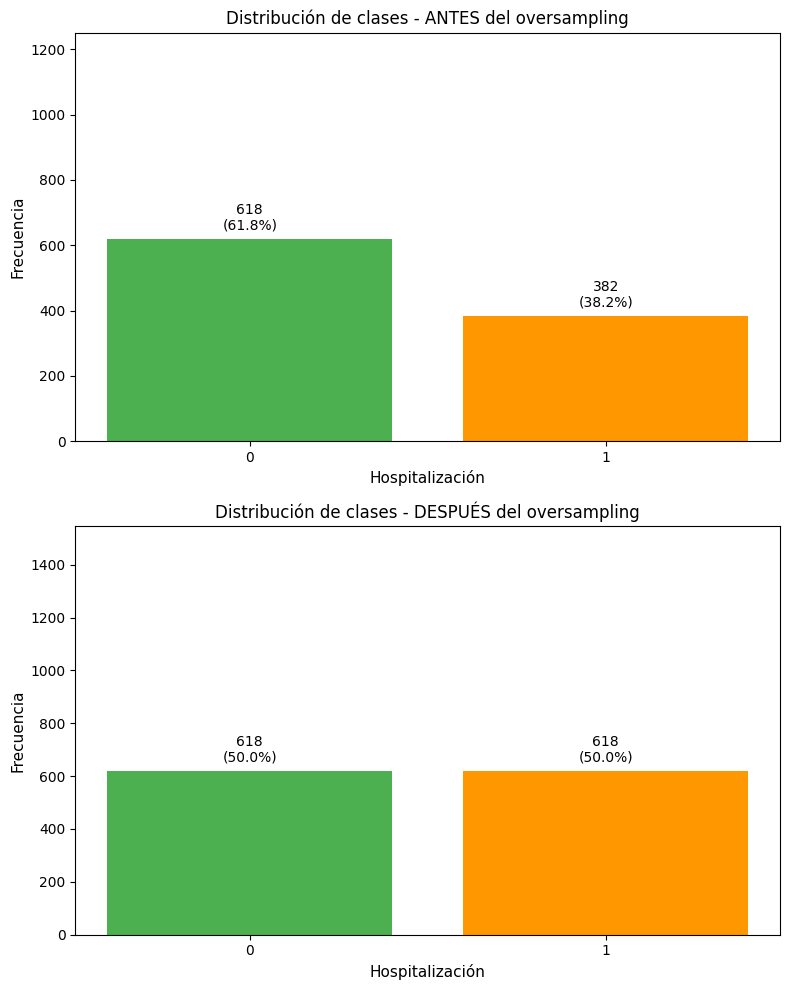

In [76]:
import matplotlib.pyplot as plt
import pandas as pd
import base64
import io
from IPython.display import display, HTML

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

counts_antes = df['hospitalizacion'].value_counts().sort_index()
total_antes = counts_antes.sum()
pct_antes = (counts_antes / total_antes * 100).round(2)

axes[0].bar(counts_antes.index.astype(str), counts_antes.values, color=['#4CAF50', '#FF9800'])
axes[0].set_xlabel('Hospitalización', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de clases - ANTES del oversampling', fontsize=12)
for i, (count, pct) in enumerate(zip(counts_antes.values, pct_antes)):
    axes[0].text(i, count + total_antes * 0.02, f'{count}\n({pct}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, total_antes * 1.25)

counts_despues = df_balanced['hospitalizacion'].value_counts().sort_index()
total_despues = counts_despues.sum()
pct_despues = (counts_despues / total_despues * 100).round(2)

axes[1].bar(counts_despues.index.astype(str), counts_despues.values, color=['#4CAF50', '#FF9800'])
axes[1].set_xlabel('Hospitalización', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Distribución de clases - DESPUÉS del oversampling', fontsize=12)
for i, (count, pct) in enumerate(zip(counts_despues.values, pct_despues)):
    axes[1].text(i, count + total_despues * 0.02, f'{count}\n({pct}%)', ha='center', va='bottom', fontsize=10)
axes[1].set_ylim(0, total_despues * 1.25)

plt.tight_layout()

buf = io.BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
buf.seek(0)
img_base64 = base64.b64encode(buf.read()).decode('utf-8')
plt.close()

display(HTML(f'''
<div style="display: flex; justify-content: center; margin-bottom: 20px;">
    <img src="data:image/png;base64,{img_base64}" 
         style="max-width: 100% !important; height: auto !important; 
                border-radius: 0 !important; box-shadow: none !important;">
</div>
'''))

Como podemos observar en las gráficas de la parte superior, al inicio de nuestra labor de minería de datos nos enfrentamos al problema de que las clases estaban desbalanceadas, teniendo una mayoría de muestras de clase 0 (pacientes no hospitalizados) que favorecía a que el modelo clasificara cualquier muestra como clase 0. Esto, en el contexto clínico, aumentaba las probabilidades de obtener un falso negativo, pero al aplicar `oversampling (sobremuestreo)`, logramos compensar por este desbalance.

## 6.2 Elaboración de conclusiones

Tras completar el análisis predictivo para el Centro de Salud Digital de Nayarit, presentamos las conclusiones fundamentales que sustentan la implementación del modelo y las recomendaciones para su uso en el contexto clínico real.

### Modelo Seleccionado y Justificación

In [77]:
grid_html = f'''
<div style="display: flex; flex-direction: column; align-items: center; gap: 30px; max-width: 95vw; margin: 0 auto;">
    <div style="width: 100%; max-width: 500px; text-align: center; font-family: 'Roboto', sans-serif;">
        <p style="font-weight: bold; font-size: 1.1em; margin-bottom: 10px;">Sin clusters</p>
        {html_sin_cluster}
    </div>
    <div style="width: 100%; max-width: 500px; text-align: center; font-family: 'Roboto', sans-serif;">
        <p style="font-weight: bold; font-size: 1.1em; margin-bottom: 10px;">Con clusters</p>
        {html_con_cluster}
    </div>
</div>
'''

display(HTML(grid_html))

,Exactitud,Precisión,Sensibilidad,F1-Score
Árbol de Decisión,81.67%,76.96%,90.27%,83.08%
Naive Bayes,73.58%,71.43%,78.38%,74.74%
Apriori,66.85%,63.48%,78.92%,70.36%
,Exactitud,Precisión,Sensibilidad,F1-Score
Árbol de Decisión,80.32%,75.69%,89.19%,81.89%
Naive Bayes,74.66%,70.97%,83.24%,76.62%
Apriori,67.12%,62.65%,84.32%,71.89%


**Conclusión principal:** El **Árbol de Decisión** (sin variables de clúster) se posiciona como el modelo óptimo para predecir hospitalización, alcanzando un **F1-Score de 0.8308** (83%) y una exactitud del 81.67%. Este rendimiento supera el umbral del 80% que consideramos aceptable para implementación en entornos clínicos.

### Factores Predictivos Más Relevantes


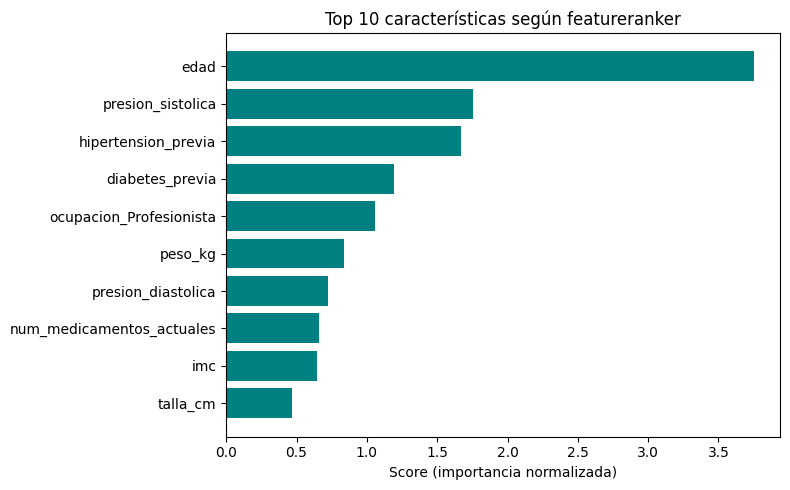

In [78]:
from IPython.display import display, HTML

display(HTML(f'''
<div style="display: flex; justify-content: center;">
    <img src="data:image/png;base64,{img_base64_franking}" style="max-width: 50vw !important; height: auto !important; border-radius: 0 !important; box-shadow: none !important;">
</div>
'''))

**Hallazgo clínico clave:** La **edad** emerge como el predictor más potente, con una puntuación muy superior al resto de variables. Esto se alinea con la evidencia médica que indica que el envejecimiento es un factor de riesgo independiente para complicaciones que requieren hospitalización. Le siguen **presión sistólica** y **hipertensión previa** , confirmando que las condiciones cardiometabólicas son determinantes críticos en el riesgo de hospitalización.

### Rendimiento del Modelo en la Práctica


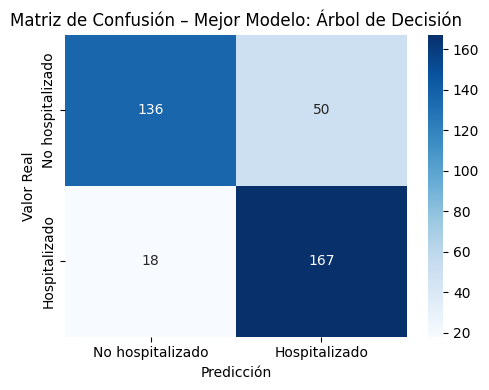

In [79]:
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import base64
import io
from IPython.display import display, HTML

modelos_candidatos = {
    'Árbol de Decisión': dt.predict(X_test),
    'Naive Bayes': gnb.predict(X_test),
    'Apriori': y_pred_apriori
}

mejor_nombre = None
mejor_f1 = -1
mejor_pred = None

for nombre, preds in modelos_candidatos.items():
    score = f1_score(y_test, preds)
    if score > mejor_f1:
        mejor_f1 = score
        mejor_nombre = nombre
        mejor_pred = preds

img_base64_ganador = generar_img_base64(y_test, mejor_pred, f'Matriz de Confusión – Mejor Modelo: {mejor_nombre}')

display(HTML(f'''
<div style="display: flex; justify-content: center; margin: 20px 0;">
    <img src="data:image/png;base64,{img_base64_ganador}" 
         style="max-width: 100% !important; height: auto !important; 
                border-radius: 0 !important; box-shadow: none !important; 
                border: none !important;">
</div>
'''))

**Interpretación clínica:** El modelo demuestra un equilibrio adecuado entre detectar pacientes que realmente requieren hospitalización (sensibilidad) y evitar alarmas innecesarias (precisión). Los **falsos negativos** (pacientes hospitalizados que el modelo clasificó como no hospitalizados) representan el error más crítico, ya que podrían retrasar la atención. Sin embargo, el rendimiento general del 83% en F1-Score indica que el modelo es confiable para apoyar la toma de decisiones.

### Impacto de las Variables de Clúster


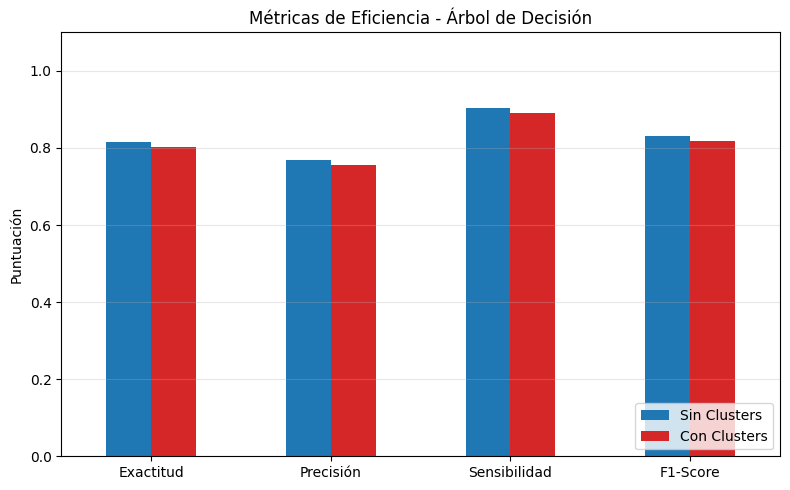
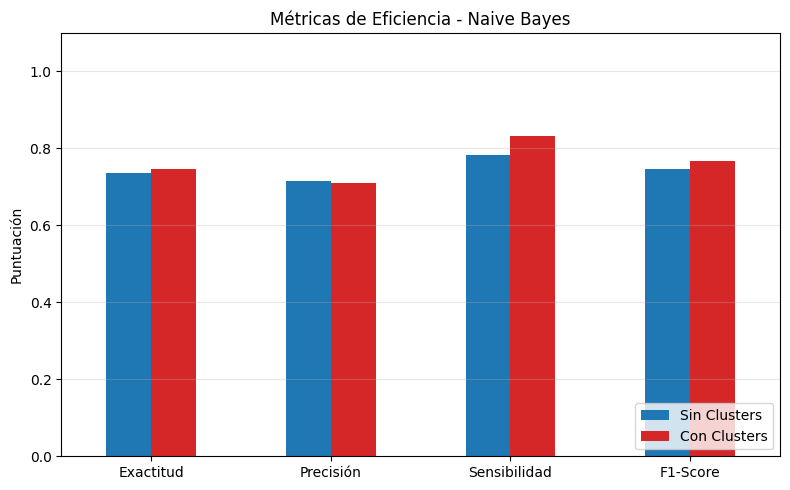
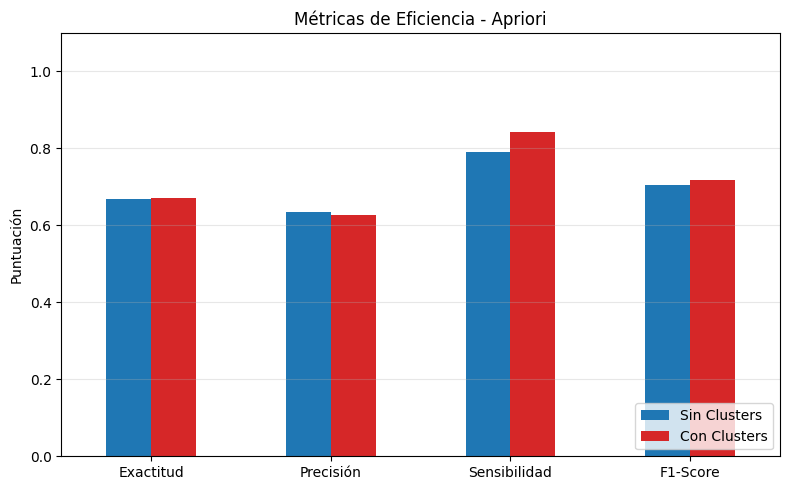

In [80]:
html_content = '<div style="display: flex; flex-direction: column; align-items: center; gap: 30px; max-width: 80vw; margin: 0 auto;">'
for img in imagenes_base64_metricas:
    html_content += f'<img src="data:image/png;base64,{img}" style="max-width: 100% !important; height: auto !important; border-radius: 0 !important; box-shadow: none !important;">'
html_content += '</div>'

display(HTML(html_content))

**Observación importante:** La inclusión de variables de clúster **no mejoró** el rendimiento del Árbol de Decisión (incluso hubo un ligero decremento de 0.8308 a 0.8189), lo que indica que el modelo ya captura eficientemente los patrones subyacentes con las variables clínicas directas. Sin embargo, para Naive Bayes y las reglas Apriori, los clústeres sí una mejora sugiriendo que esta técnica de ingeniería de características beneficia principalmente a modelos más simples.

### Recomendaciones para Implementación

Se recomienda implementar el Árbol de Decisión como herramienta de apoyo a la decisión clínica, priorizando el monitoreo de pacientes con factores de alto riesgo. Para garantizar su eficacia, es esencial capacitar al personal en la interpretación de predicciones y protocolos de actuación, además de realizar una reevaluación y reentrenamiento del modelo cada 6-12 meses para mitigar la deriva temporal de los datos.

### Limitaciones y Trabajo Futuro

Aunque el modelo demuestra un rendimiento sólido, es importante reconocer sus limitaciones para una implementación responsable:

- **Tamaño muestral:** Con ~1,000 registros tras limpieza, el dataset es relativamente pequeño. Se recomienda recolectar más datos históricos para mejorar la generalización.
- **Modelos más complejos:** Futuras iteraciones podrían explorar Random Forest, XGBoost o redes neuronales, que podrían capturar interacciones no lineales más complejas.
- **Variables socioeconómicas:** Aunque se incluyeron algunas, factores como ingreso, acceso a transporte o apoyo familiar podrían mejorar la predicción.


### Conclusión Final

La implementación del **Árbol de Decisión** permitirá al Centro de Salud Digital de Nayarit **anticipar la necesidad de hospitalización** con 81% de precisión, optimizando la asignación de camas y personal, reduciendo tiempos de espera en urgencias y, lo más importante, **mejorando la atención al paciente** mediante intervenciones proactivas basadas en evidencia predictiva.